<a href="https://colab.research.google.com/github/aniket-mendhe/Google-Play-Store/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the Data


In [1]:
import pandas as pd

In [2]:
trades = pd.read_csv("/content/historical_data.csv")
sentiments = pd.read_csv("/content/fear_greed_index.csv")

In [3]:
print(trades.head())
print(sentiments.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [5]:
print(trades.shape)
print(sentiments.shape)

(211224, 16)
(2644, 4)


In [6]:
print(trades.info())
print(sentiments.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

Check Missing Values and Duplicates

In [7]:
trades.isna().sum()
sentiments.isna().sum()

trades.duplicated().sum()
sentiments.duplicated().sum()

np.int64(0)

In [8]:
trades = trades.drop_duplicates()
sentiments = sentiments.drop_duplicates()

Fix date and time columns

In [11]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date
sentiments['date'] = pd.to_datetime(sentiments['date'])
sentiments['date'] = sentiments['date'].dt.date

Merge Datasets by Date

In [12]:
df = pd.merge(trades, sentiments, on='date', how='left')

In [13]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


Create Daily Metrics

In [15]:
daily_pnl = df.groupby(['date', 'Account'])['Closed PnL'].sum().reset_index()

In [17]:
# trades per day
trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

In [20]:
#average trades size
avg_size = df.groupby('date')['Size Tokens'].mean().reset_index(name='avg_size')


In [26]:
#Leverage distribution
leverage_stats = df.groupby('date').describe().reset_index()

In [28]:
#Long short ratio
long_short = df.groupby(['date', 'Side']).size().unstack(fill_value=0)
long_short['long_short_ratio'] = long_short['BUY'] / long_short['SELL']

Analysis

Performance on fear vs greed day

In [30]:
performance  = df.groupby('classification')['Closed PnL'].agg(['mean', 'sum', 'count'])

In [31]:
performance

,mean,sum,count
classification,,,
Extreme Fear,34.537862,7.391102e+05,21400
Extreme Greed,67.892861,2.715171e+06,39992
Fear,54.290400,3.357155e+06,61837
Greed,42.743559,2.150129e+06,50303
Neutral,34.307718,1.292921e+06,37686


behaviour Changes

In [34]:
behaviour = df.groupby('classification').agg({'Size Tokens': 'mean', 'Closed PnL': 'mean'})

In [35]:
behaviour

,Size Tokens,Closed PnL
classification,,
Extreme Fear,1675.893319,34.537862
Extreme Greed,8832.415746,67.892861
Fear,2992.641845,54.290400
Greed,4715.327756,42.743559
Neutral,4383.368714,34.307718


Create 2-3 Trader segments

In [40]:
trade_count = df.groupby('Account').size()

In [41]:
trade_count

,0
Account,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
0x271b280974205ca63b716753467d5a371de622ab,3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,815
0x39cef799f8b69da1995852eea189df24eb5cae3c,3589
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,332
0x420ab45e0bd8863569a5efbb9c05d91f40624641,383


BAR CHART

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

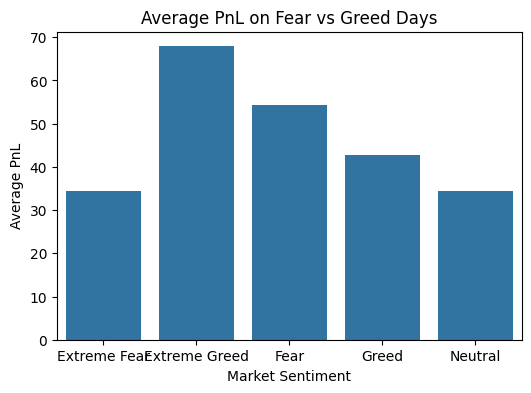

In [44]:
avg_pnl = df.groupby('classification')['Closed PnL'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=avg_pnl, x='classification', y='Closed PnL')
plt.title("Average PnL on Fear vs Greed Days")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")
plt.show()

BOX PLOT

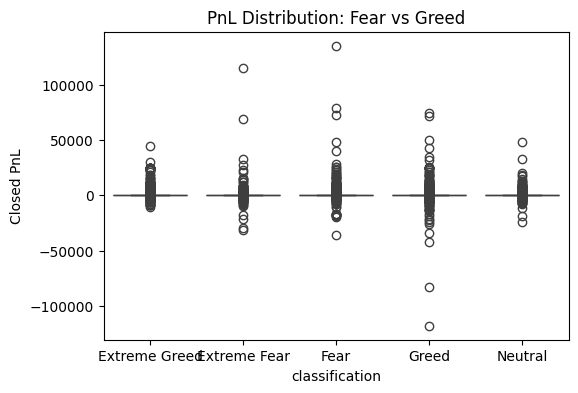

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='classification', y='Closed PnL')
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

Line Chart

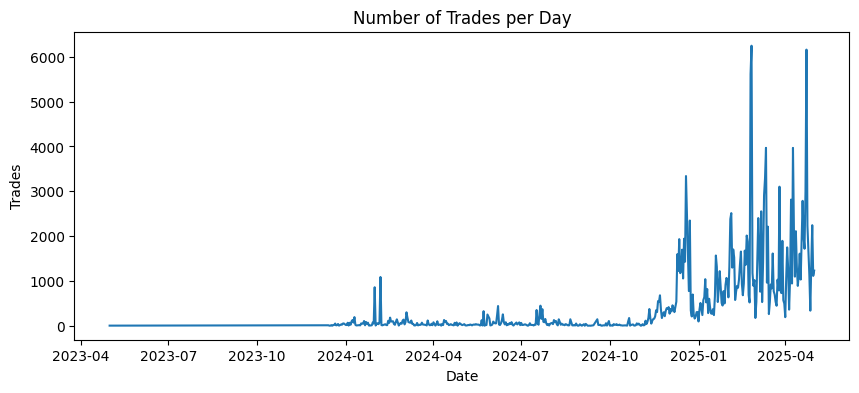

In [51]:
trades_per_day = df.groupby('date').size().reset_index(name='num_trades')

plt.figure(figsize=(10,4))
plt.plot(trades_per_day['date'], trades_per_day['num_trades'])
plt.title("Number of Trades per Day")
plt.xlabel("Date")
plt.ylabel("Trades")
plt.show()